# Berlin Analytics Warehouse — Insights Notebook

This notebook explores the **Berlin Analytics Warehouse**, which combines:

- cleaned Berlin bike counter data from the **Berlin Mobility Pipeline**
- historical Berlin weather data from the **Berlin Weather Pipeline**

The goal is to move beyond the technical pipeline and discover useful patterns in the data.

## Main questions

1. What does Berlin bike traffic look like over time?
2. Which stations record the highest bike traffic?
3. How does bike traffic vary by hour, weekday, and month?
4. What weather patterns are visible in the 2025 weather data?
5. How does bike traffic relate to temperature and rain?

> Note: The analysis is exploratory. The charts can suggest patterns, but they do not prove causality.

## 1. Setup

This section loads the local DuckDB warehouse created by `src/ingest.py`.

Expected database path:

```text
../data/processed/warehouse.duckdb
```

In [2]:
import sys
!{sys.executable} -m pip install duckdb pandas matplotlib pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 5.9 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 7.0 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [duckdb]2m1/2 [duckdb]


In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

DB_PATH = Path("../data/processed/warehouse.duckdb")
FIGURES_DIR = Path("../Reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"{DB_PATH} does not exist. Run `python3 src/ingest.py` from the project root first."
    )

con = duckdb.connect(str(DB_PATH))

print("Connected to warehouse:", DB_PATH)

Connected to warehouse: ../data/processed/warehouse.duckdb


In [2]:
tables = con.execute("SHOW TABLES").df()
tables

,name
0,dim_date
1,dim_station
2,dim_weather
3,fact_bike_counts


## 2. Data overview

Before creating visuals, check how many records are available in the main warehouse tables.

In [3]:
table_counts = con.execute("""
    SELECT 'fact_bike_counts' AS table_name, COUNT(*) AS row_count FROM fact_bike_counts
    UNION ALL
    SELECT 'dim_date' AS table_name, COUNT(*) AS row_count FROM dim_date
    UNION ALL
    SELECT 'dim_station' AS table_name, COUNT(*) AS row_count FROM dim_station
    UNION ALL
    SELECT 'dim_weather' AS table_name, COUNT(*) AS row_count FROM dim_weather
""").df()

table_counts

,table_name,row_count
0,fact_bike_counts,306600
1,dim_date,365
2,dim_station,35
3,dim_weather,365


In [4]:
date_range = con.execute("""
    SELECT
        MIN(date_id) AS first_date,
        MAX(date_id) AS last_date,
        COUNT(DISTINCT date_id) AS number_of_days
    FROM fact_bike_counts
""").df()

date_range

,first_date,last_date,number_of_days
0,2025-01-01,2025-12-31,365


### Initial observation

At this point, the warehouse should contain:

- many bike count observations in `fact_bike_counts`
- one date dimension table
- one station dimension table
- one daily weather dimension table

This confirms that the first two pipelines were successfully connected into one analytics model.

## 3. Monthly bike traffic trend

Question: **Which months show the highest bike traffic?**

This chart aggregates bike counts by month.

In [5]:
monthly = con.execute("""
    SELECT
        d.month,
        SUM(f.bike_count) AS total_bikes
    FROM fact_bike_counts AS f
    JOIN dim_date AS d
        ON f.date_id = d.date_id
    GROUP BY d.month
    ORDER BY d.month
""").df()

monthly["month_name"] = pd.to_datetime(monthly["month"], format="%m").dt.strftime("%b")
monthly

,month,total_bikes,month_name
0,1,1606969.0,Jan
1,2,1500069.0,Feb
2,3,2559199.0,Mar
3,4,2726971.0,Apr
4,5,2858150.0,May
5,6,3029578.0,Jun
6,7,2890633.0,Jul
7,8,2694910.0,Aug
8,9,2873717.0,Sep
9,10,2164463.0,Oct


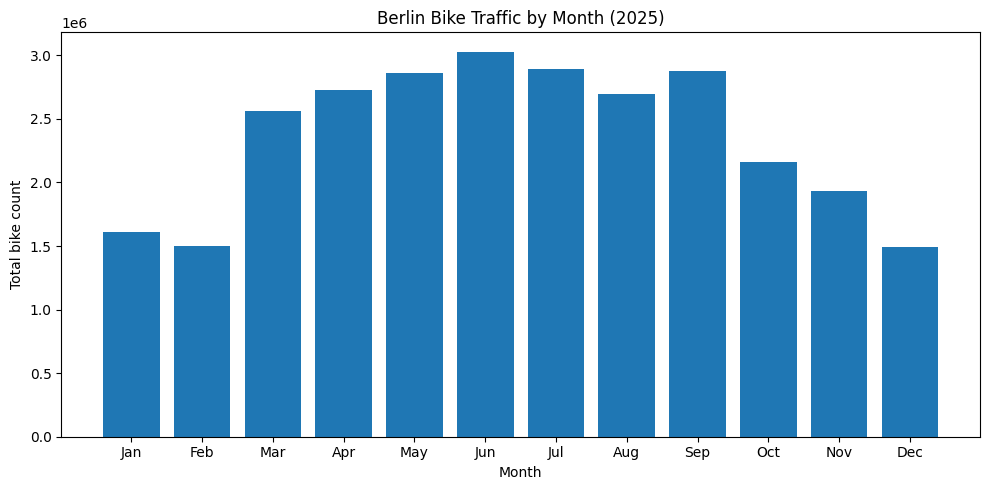

In [6]:
plt.figure(figsize=(10, 5))
plt.bar(monthly["month_name"], monthly["total_bikes"])
plt.title("Berlin Bike Traffic by Month (2025)")
plt.xlabel("Month")
plt.ylabel("Total bike count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_trend.png", dpi=300)
plt.show()

In [7]:
best_month = monthly.loc[monthly["total_bikes"].idxmax()]
lowest_month = monthly.loc[monthly["total_bikes"].idxmin()]

print(f"Highest traffic month: {best_month['month_name']} with {best_month['total_bikes']:,.0f} bike counts")
print(f"Lowest traffic month: {lowest_month['month_name']} with {lowest_month['total_bikes']:,.0f} bike counts")

Highest traffic month: Jun with 3,029,578 bike counts
Lowest traffic month: Dec with 1,495,094 bike counts


### Insight

The monthly bike traffic pattern shows a clear seasonal trend. The highest recorded traffic appears in **June**, with about **3.03 million bike counts**, while the lowest traffic appears in **December**, with about **1.50 million bike counts**.

This suggests that bike traffic in Berlin is much stronger during warmer months and lower during winter. Possible explanations include better cycling conditions, longer daylight hours, commuting behavior, tourism, and reduced cycling during colder or darker periods.

This result should not be interpreted as proof that temperature alone causes the increase. Other factors, such as holidays, working patterns, station locations, and city activity, may also influence the monthly traffic pattern.

The next step is to compare this seasonal bike traffic pattern with weather variables such as temperature and precipitation.

## 4. Hourly bike traffic pattern

Question: **At what time of day is bike traffic highest?**

This chart shows the average bike count by hour.

In [8]:
hourly = con.execute("""
    SELECT
        hour,
        AVG(bike_count) AS avg_bikes
    FROM fact_bike_counts
    GROUP BY hour
    ORDER BY hour
""").df()

hourly

,hour,avg_bikes
0,0,22.026441
1,1,12.208750
2,2,7.207182
3,3,5.050187
4,4,6.464422
5,5,17.623620
6,6,36.719562
7,7,99.616790
8,8,163.095624
9,9,133.732666


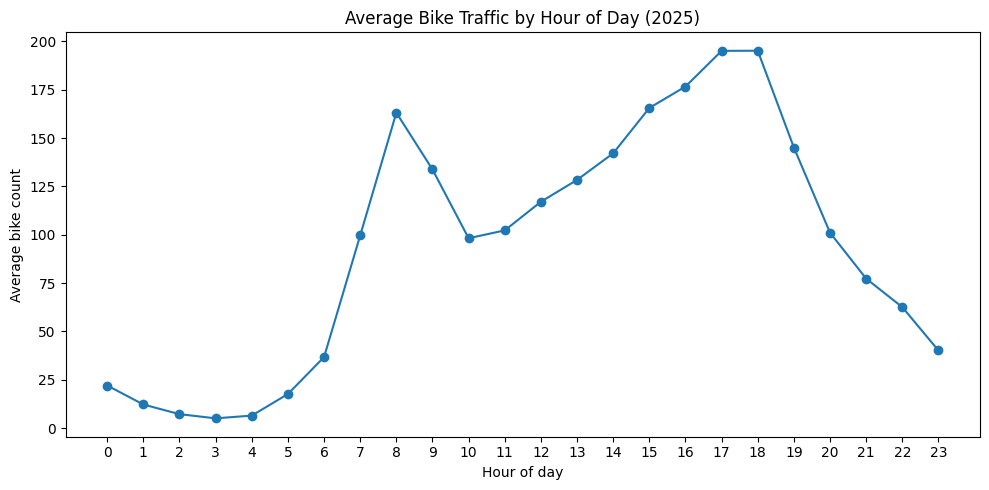

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(hourly["hour"], hourly["avg_bikes"], marker="o")
plt.title("Average Bike Traffic by Hour of Day (2025)")
plt.xlabel("Hour of day")
plt.ylabel("Average bike count")
plt.xticks(hourly["hour"])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "hourly_pattern.png", dpi=300)
plt.show()

In [10]:
peak_hour = hourly.loc[hourly["avg_bikes"].idxmax()]
print(f"Peak traffic hour: {int(peak_hour['hour'])}:00 with an average of {peak_hour['avg_bikes']:.2f} bike counts")

Peak traffic hour: 18:00 with an average of 195.14 bike counts


### Insight

The hourly pattern shows two clear traffic peaks during the day. The first strong increase appears in the morning around **08:00**, which likely reflects commuting or school-related trips. The highest average bike traffic appears around **18:00**, with an average of about **195 bike counts**.

This pattern suggests that Berlin bike traffic is strongly connected to daily movement routines. The morning peak may represent trips into work or school, while the stronger late-afternoon and early-evening peak may reflect return trips, leisure cycling, or after-work activity.

Traffic is very low during the night and early morning hours, especially between **01:00 and 04:00**, which supports the interpretation that most recorded cycling activity is linked to daytime mobility.

This is an observational pattern, not proof of individual travel behavior. To understand the pattern better, it would be useful to compare weekdays and weekends separately.

## 5. Top bike counting stations

Question: **Which stations record the highest total bike traffic?**

In [11]:
top_stations = con.execute("""
    SELECT
        station_name,
        SUM(bike_count) AS total_bikes
    FROM fact_bike_counts
    GROUP BY station_name
    ORDER BY total_bikes DESC
    LIMIT 10
""").df()

top_stations

,station_name,total_bikes
0,05-FK-OBB-O,2087711.0
1,05-FK-OBB-W,1951446.0
2,21-NK-MAY,1639918.0
3,09-PA-SA-S,1321849.0
4,02-MI-JAN-N,1261310.0
5,02-MI-JAN-S,1216636.0
6,07-FK-ST,1173742.0
7,01-MI-AL-W,1112192.0
8,10-PA-BER-N,1107863.0
9,11-PA-SE-N,1097248.0


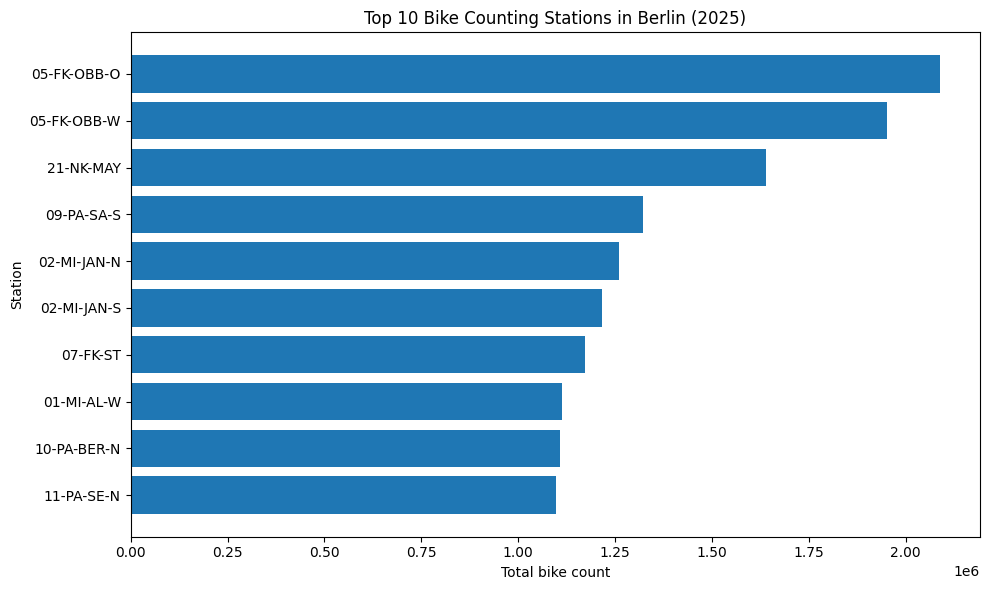

In [12]:
plt.figure(figsize=(10, 6))
plt.barh(top_stations["station_name"], top_stations["total_bikes"])
plt.title("Top 10 Bike Counting Stations in Berlin (2025)")
plt.xlabel("Total bike count")
plt.ylabel("Station")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_stations.png", dpi=300)
plt.show()

In [13]:
top_station = top_stations.iloc[0]
print(f"Busiest station: {top_station['station_name']} with {top_station['total_bikes']:,.0f} bike counts")

Busiest station: 05-FK-OBB-O with 2,087,711 bike counts


### Insight

The station-level analysis shows that bike traffic is not evenly distributed across all counting stations. The busiest station is **05-FK-OBB-O**, with about **2.09 million bike counts** in 2025.

The second-highest station, **05-FK-OBB-W**, is also very close to the top result. This suggests that the area represented by the `05-FK-OBB` counting direction is one of the most active cycling corridors in the dataset.

Several other stations also record more than one million bike counts, but the top two stations clearly stand out. This may indicate important commuting routes, central cycling infrastructure, or high-volume urban mobility corridors.

A limitation is that station IDs alone do not immediately explain the exact geographic context. A future improvement would be to enrich the station dimension with station names, coordinates, or district information so that the results can be interpreted geographically.

## 6. Weekday vs weekend bike traffic

Question: **Is bike traffic different on weekdays and weekends?**

In [14]:
weekday_weekend = con.execute("""
    SELECT
        CASE
            WHEN d.is_weekend THEN 'Weekend'
            ELSE 'Weekday'
        END AS day_type,
        AVG(f.bike_count) AS avg_bikes
    FROM fact_bike_counts AS f
    JOIN dim_date AS d
        ON f.date_id = d.date_id
    GROUP BY day_type
    ORDER BY day_type
""").df()

weekday_weekend

,day_type,avg_bikes
0,Weekday,105.273784
1,Weekend,64.858011


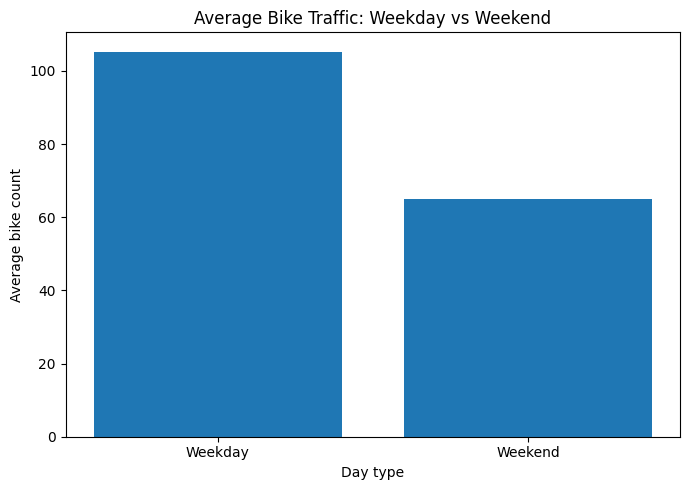

In [15]:
plt.figure(figsize=(7, 5))
plt.bar(weekday_weekend["day_type"], weekday_weekend["avg_bikes"])
plt.title("Average Bike Traffic: Weekday vs Weekend")
plt.xlabel("Day type")
plt.ylabel("Average bike count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "weekday_vs_weekend.png", dpi=300)
plt.show()

### Insight

The weekday vs weekend comparison shows that average bike traffic is higher on weekdays than on weekends. Weekdays show an average of about **105 bike counts**, while weekends show about **65 bike counts**.

This suggests that a large part of recorded bike traffic may be related to regular weekday mobility, such as commuting to work, school, university, or other routine trips. Weekend cycling still remains relevant, but the lower average indicates a different mobility pattern.

This result supports the hourly traffic pattern seen earlier: strong morning and late-afternoon peaks are likely connected to weekday commuting behavior.

A limitation is that this comparison only separates days into weekday and weekend. A deeper analysis could compare each weekday separately, or combine weekday/weekend patterns with hourly traffic to see whether commuting peaks are mainly a weekday effect.

## 7. Weather overview

Question: **What weather patterns are visible in the 2025 weather data?**

This section summarizes daily temperature, precipitation, and wind speed.

In [16]:
weather_summary = con.execute("""
    SELECT
        MIN(avg_temp_c) AS min_avg_temp_c,
        AVG(avg_temp_c) AS mean_avg_temp_c,
        MAX(avg_temp_c) AS max_avg_temp_c,
        SUM(total_precipitation_mm) AS yearly_precipitation_mm,
        AVG(avg_wind_speed) AS mean_wind_speed
    FROM dim_weather
""").df()

weather_summary

,min_avg_temp_c,mean_avg_temp_c,max_avg_temp_c,yearly_precipitation_mm,mean_wind_speed
0,-7.4,10.652751,29.654167,610.5,10.599178


In [17]:
monthly_weather = con.execute("""
    SELECT
        CAST(SUBSTR(date_id, 6, 2) AS INTEGER) AS month,
        AVG(avg_temp_c) AS avg_temp_c,
        SUM(total_precipitation_mm) AS total_precipitation_mm
    FROM dim_weather
    GROUP BY month
    ORDER BY month
""").df()

monthly_weather["month_name"] = pd.to_datetime(monthly_weather["month"], format="%m").dt.strftime("%b")
monthly_weather

,month,avg_temp_c,total_precipitation_mm,month_name
0,1,2.239651,82.5,Jan
1,2,0.610268,22.3,Feb
2,3,6.215054,13.5,Mar
3,4,11.963611,15.8,Apr
4,5,13.812097,24.5,May
5,6,19.681528,48.6,Jun
6,7,19.553226,185.8,Jul
7,8,18.848925,40.4,Aug
8,9,15.675278,53.9,Sep
9,10,10.251613,54.3,Oct


In [29]:
monthly_weather.sort_values("total_precipitation_mm", ascending=False)

,month,avg_temp_c,total_precipitation_mm,month_name
6,7,19.553226,185.8,Jul
0,1,2.239651,82.5,Jan
9,10,10.251613,54.3,Oct
8,9,15.675278,53.9,Sep
10,11,5.209167,49.4,Nov
5,6,19.681528,48.6,Jun
7,8,18.848925,40.4,Aug
4,5,13.812097,24.5,May
1,2,0.610268,22.3,Feb
11,12,3.120699,19.5,Dec


In [32]:
con = duckdb.connect(str(DB_PATH))

In [33]:
july_rain = con.execute("""
    SELECT
        date_id,
        total_precipitation_mm
    FROM dim_weather
    WHERE SUBSTR(date_id, 6, 2) = '07'
    ORDER BY total_precipitation_mm DESC
""").df()

july_rain.head(10)

,date_id,total_precipitation_mm
0,2025-07-21,44.3
1,2025-07-23,25.3
2,2025-07-12,23.2
3,2025-07-17,15.3
4,2025-07-13,11.0
5,2025-07-22,9.4
6,2025-07-14,8.1
7,2025-07-25,7.6
8,2025-07-07,6.6
9,2025-07-11,6.5


### July precipitation check

July appears as the month with the highest total precipitation in the dataset, with about **185.8 mm**. Although July is a summer month, this does not necessarily indicate constant rain throughout the month.

The daily precipitation check shows that July’s high monthly total is partly driven by a few strong rain events. The highest daily precipitation appears on **2025-07-21**, with about **44.3 mm**, followed by other heavy-rain days such as **2025-07-23** and **2025-07-12**.

This suggests that the high July precipitation value is plausible and likely caused by short but intense summer rain events rather than evenly distributed rainfall across the whole month.

For the mobility analysis, this means monthly precipitation should be interpreted carefully. A high monthly total may hide very different daily patterns, so daily-level analysis is more useful when comparing rain and bike traffic.

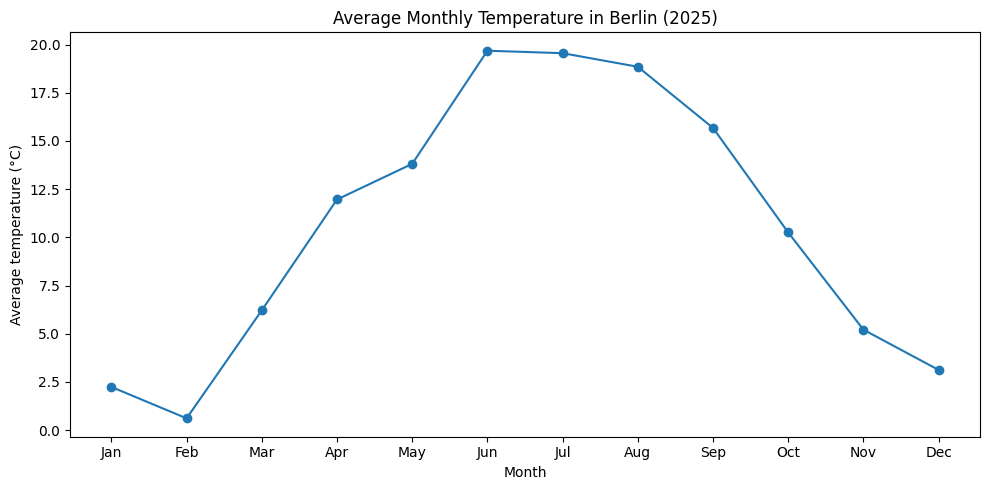

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_weather["month_name"], monthly_weather["avg_temp_c"], marker="o")
plt.title("Average Monthly Temperature in Berlin (2025)")
plt.xlabel("Month")
plt.ylabel("Average temperature (°C)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_temperature.png", dpi=300)
plt.show()

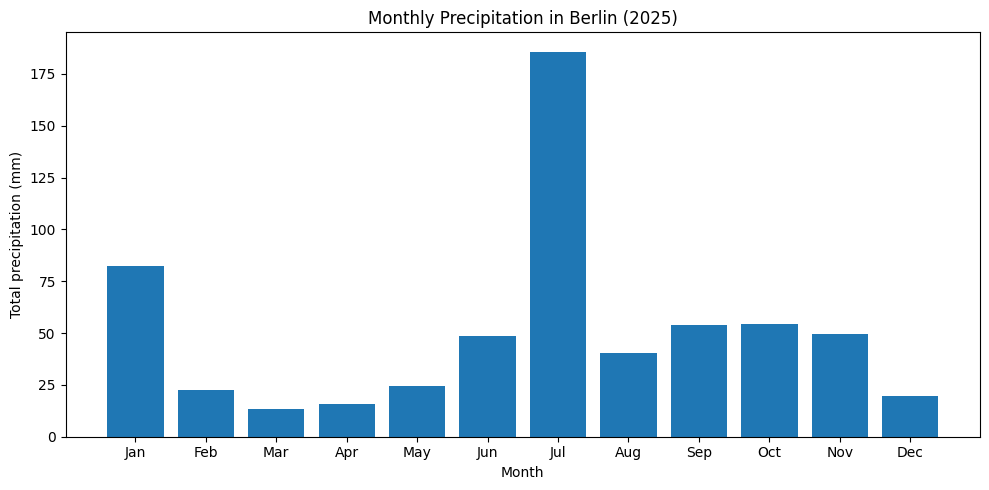

In [35]:
plt.figure(figsize=(10, 5))
plt.bar(monthly_weather["month_name"], monthly_weather["total_precipitation_mm"])
plt.title("Monthly Precipitation in Berlin (2025)")
plt.xlabel("Month")
plt.ylabel("Total precipitation (mm)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_precipitation.png", dpi=300)
plt.show()

### Insight

The weather overview shows a clear seasonal pattern in Berlin’s 2025 weather data. Average monthly temperature rises from winter into summer, reaching its highest level around **June and July** at about **19–20°C**, before decreasing again toward the end of the year.

Precipitation is less smooth than temperature. The chart shows a particularly high precipitation value in **July**, with about **186 mm**, while several spring months have much lower precipitation. This means that weather conditions in the dataset vary not only by season, but also by individual months.

These weather patterns are important because they provide context for the bike traffic analysis. Temperature may be related to higher cycling activity during warmer months, while precipitation may help explain lower cycling activity on rainy days.

However, weather should be interpreted as one possible factor, not the only explanation. Bike traffic can also be influenced by holidays, commuting behavior, tourism, daylight, infrastructure, and station location.

## 8. Bike traffic and temperature

Question: **How does bike traffic relate to average daily temperature?**

This is one of the most important analyses because it combines the mobility and weather pipelines.

In [36]:
daily_temp = con.execute("""
    SELECT
        f.date_id,
        SUM(f.bike_count) AS total_bike_count,
        AVG(w.avg_temp_c) AS avg_temp_c
    FROM fact_bike_counts AS f
    JOIN dim_weather AS w
        ON f.date_id = w.date_id
    GROUP BY f.date_id
    ORDER BY f.date_id
""").df()

daily_temp["date_id"] = pd.to_datetime(daily_temp["date_id"])
daily_temp.head()

,date_id,total_bike_count,avg_temp_c
0,2025-01-01,17521.0,4.566667
1,2025-01-02,45758.0,4.258333
2,2025-01-03,41708.0,0.875000
3,2025-01-04,29296.0,-1.112500
4,2025-01-05,18849.0,-1.116667


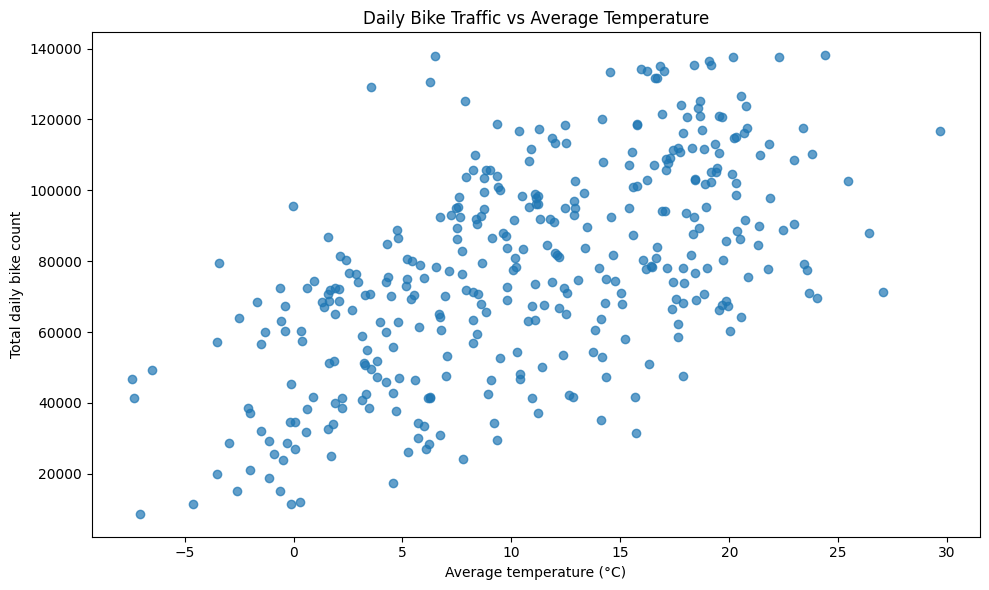

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(daily_temp["avg_temp_c"], daily_temp["total_bike_count"], alpha=0.7)
plt.title("Daily Bike Traffic vs Average Temperature")
plt.xlabel("Average temperature (°C)")
plt.ylabel("Total daily bike count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "daily_bike_traffic_vs_temperature.png", dpi=300)
plt.show()

In [22]:
correlation = daily_temp["avg_temp_c"].corr(daily_temp["total_bike_count"])
print(f"Correlation between average temperature and total daily bike traffic: {correlation:.3f}")

Correlation between average temperature and total daily bike traffic: 0.598


### Insight

The scatter plot shows a positive relationship between average daily temperature and total daily bike traffic. Warmer days tend to be associated with higher bike counts, while colder days generally show lower cycling activity.

The calculated correlation is about **0.598**, which suggests a moderate positive relationship between temperature and bike traffic. This supports the earlier monthly analysis, where bike traffic was higher during warmer months and lower during winter.

However, this relationship should not be interpreted as proof that temperature alone causes higher bike traffic. Temperature is connected to seasonality, daylight hours, holidays, tourism, and general outdoor activity. These factors may also influence cycling behavior.

Overall, the chart suggests that weather context is useful for understanding bike traffic patterns, especially when combined with other variables such as precipitation, weekday/weekend patterns, and hourly traffic.

## 9. Bike traffic on rainy vs dry days

Question: **Is average bike traffic different on rainy days compared with dry days?**

In [38]:
rain_vs_dry = con.execute("""
    SELECT
        CASE
            WHEN w.total_precipitation_mm > 1 THEN 'Rainy'
            ELSE 'Dry'
        END AS weather_type,
        AVG(f.bike_count) AS avg_bikes,
        COUNT(DISTINCT f.date_id) AS number_of_days
    FROM fact_bike_counts AS f
    JOIN dim_weather AS w
        ON f.date_id = w.date_id
    GROUP BY weather_type
    ORDER BY weather_type
""").df()

rain_vs_dry

,weather_type,avg_bikes,number_of_days
0,Dry,98.191315,253
1,Rainy,83.764874,112


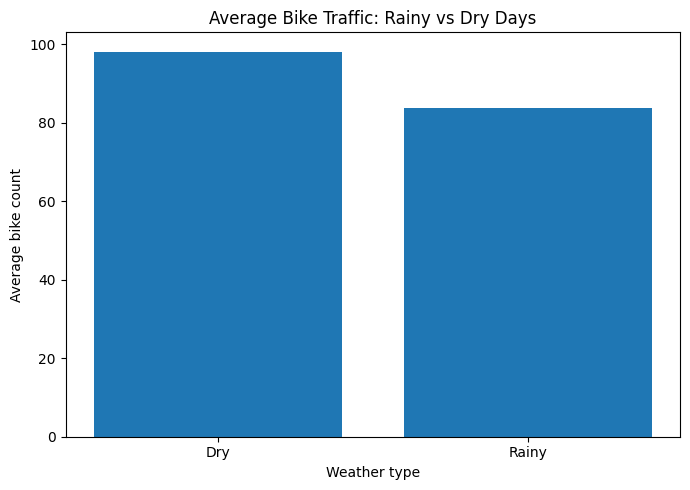

In [39]:
plt.figure(figsize=(7, 5))
plt.bar(rain_vs_dry["weather_type"], rain_vs_dry["avg_bikes"])
plt.title("Average Bike Traffic: Rainy vs Dry Days")
plt.xlabel("Weather type")
plt.ylabel("Average bike count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rain_vs_dry.png", dpi=300)
plt.show()

### Insight

The rainy vs dry day comparison shows that average bike traffic is lower on rainy days than on dry days. Dry days have an average of about **98 bike counts**, while rainy days have an average of about **84 bike counts**.

This suggests that precipitation may be associated with reduced cycling activity. Rain can make cycling less comfortable or less attractive, especially for non-essential trips.

However, this result should be interpreted carefully. The chart only compares two broad categories and does not control for other factors such as temperature, weekday/weekend differences, holidays, or seasonality. For example, rainy days may also occur in colder months, which could partly explain the lower traffic.

A stronger future analysis would compare bike traffic across different precipitation levels, or combine rain, temperature, and weekday/weekend information in one model.

## 10. Bike traffic by temperature range

Question: **Which temperature ranges are associated with higher bike traffic?**

In [40]:
daily_temp["temperature_bin"] = pd.cut(
    daily_temp["avg_temp_c"],
    bins=[-20, 0, 5, 10, 15, 20, 25, 35],
    labels=["<0", "0–5", "5–10", "10–15", "15–20", "20–25", "25+"],
)

temp_bins = (
    daily_temp
    .groupby("temperature_bin", observed=True)
    .agg(
        avg_daily_bike_count=("total_bike_count", "mean"),
        number_of_days=("date_id", "count"),
    )
    .reset_index()
)

temp_bins

,temperature_bin,avg_daily_bike_count,number_of_days
0,<0,41484.906250,32
1,0–5,58070.258065,62
2,5–10,74128.402597,77
3,10–15,81246.314286,70
4,15–20,95916.459770,87
5,20–25,99563.575758,33
6,25+,94700.000000,4


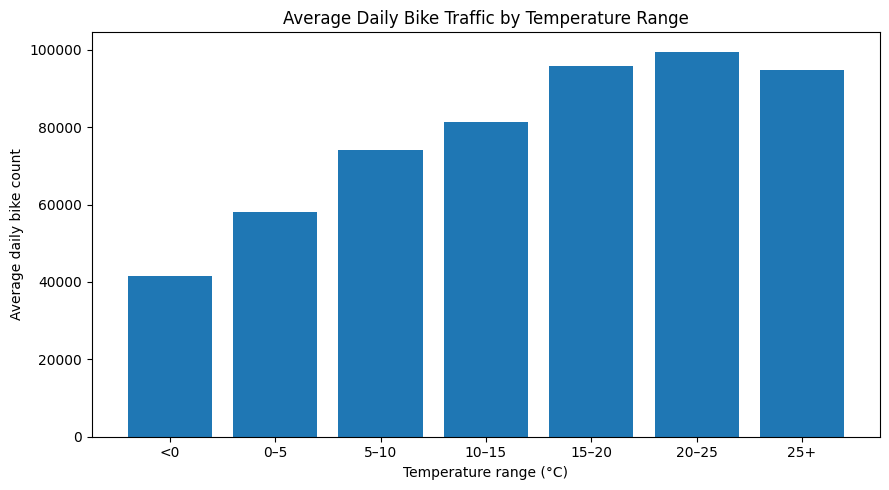

In [41]:
plt.figure(figsize=(9, 5))
plt.bar(temp_bins["temperature_bin"].astype(str), temp_bins["avg_daily_bike_count"])
plt.title("Average Daily Bike Traffic by Temperature Range")
plt.xlabel("Temperature range (°C)")
plt.ylabel("Average daily bike count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bike_traffic_by_temperature_range.png", dpi=300)
plt.show()

### Insight

Grouping temperature into ranges makes the relationship between weather and cycling activity easier to interpret. The chart shows that average daily bike traffic generally increases as temperatures become warmer.

Very cold days below **0°C** have the lowest average bike traffic, with about **41,000 daily bike counts**. Traffic increases steadily through the mild temperature ranges and reaches its highest level around **20–25°C**, with about **99,000 daily bike counts**.

Interestingly, the **25°C+** group is slightly lower than the 20–25°C group. This may suggest that very warm days do not necessarily produce the highest cycling activity, or it may simply reflect the small number of very hot days in the dataset.

Overall, the chart suggests that moderate to warm weather is associated with higher bike traffic, while cold conditions are associated with lower cycling activity. This supports the earlier scatter plot and correlation analysis.

## 11. Key insights

This notebook shows how the Berlin Analytics Warehouse can be used to move from raw pipeline outputs to analytical insights.

### 1. Bike traffic has a clear seasonal pattern

Bike traffic is highest in the warmer months and lowest in winter. The highest monthly traffic appears in **June**, with about **3.03 million bike counts**, while the lowest appears in **December**, with about **1.50 million bike counts**.

This suggests that cycling activity in Berlin is strongly seasonal.

### 2. Daily mobility patterns show commuting behavior

The hourly analysis shows clear daily peaks. A strong morning increase appears around **08:00**, and the highest average traffic appears around **18:00**, with about **195 average bike counts**.

This pattern suggests that many bike trips are connected to regular daily routines such as commuting, school, university, or after-work mobility.

### 3. Weekday traffic is higher than weekend traffic

Weekdays show higher average bike traffic than weekends. This supports the interpretation that a large part of recorded bike traffic is connected to weekday mobility patterns.

### 4. Bike traffic is concentrated at specific counting stations

The top station, **05-FK-OBB-O**, records about **2.09 million bike counts**. This indicates that some counting locations represent especially important cycling corridors.

A future improvement would be to enrich the station dimension with geographic information such as district, street name, or coordinates.

### 5. Weather context helps explain mobility patterns

Temperature and bike traffic show a moderate positive relationship. The correlation between average daily temperature and total daily bike traffic is about **0.598**.

This suggests that warmer days are generally associated with higher bike traffic, although this does not prove that temperature alone causes the increase.

### 6. Rainy days show lower average bike traffic

Dry days show about **98 average bike counts**, while rainy days show about **84 average bike counts**. This suggests that precipitation may be associated with reduced cycling activity.

However, the result should be interpreted carefully because rainy days may also differ in temperature, season, weekday/weekend distribution, and other factors.

### 7. The value of connecting the three projects

The most important portfolio result is not only the individual charts. The key result is that three separate projects now work together:

```text
Berlin Mobility Pipeline
→ Berlin Weather Pipeline
→ Berlin Analytics Warehouse
→ Insights notebook

## 12. Limitations and next steps

### Limitations

- The analysis is exploratory and does not prove causality.
- Bike traffic may be influenced by holidays, public events, construction, station location, daylight, tourism, and commuting behavior.
- Weather is aggregated daily, while bike counts are available hourly. This limits detailed hour-by-hour weather comparison.
- The station dimension currently uses station IDs but does not include geographic metadata such as district, coordinates, or street names.
- The warehouse currently depends on locally generated outputs from the first two projects.

### Next steps

- Add weekday vs weekend hourly comparison to better analyze commuting behavior.
- Add holiday and public event context.
- Enrich stations with geographic metadata.
- Compare station-level behavior across different weather conditions.
- Add more advanced statistical analysis.
- Improve CI so the warehouse can be tested automatically with small fixture datasets.
- Build a FastAPI layer to query the warehouse data.

In [27]:
con.close()
print("Connection closed.")

Connection closed.
